#### Импорты, seed и среда

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import os
from datetime import datetime

# фиксируем seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

#### Данные и первичный анализ

Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 → 2025-06-29 23:00:00
Пропуски по колонкам:
 date      0
target    0
dtype: int64


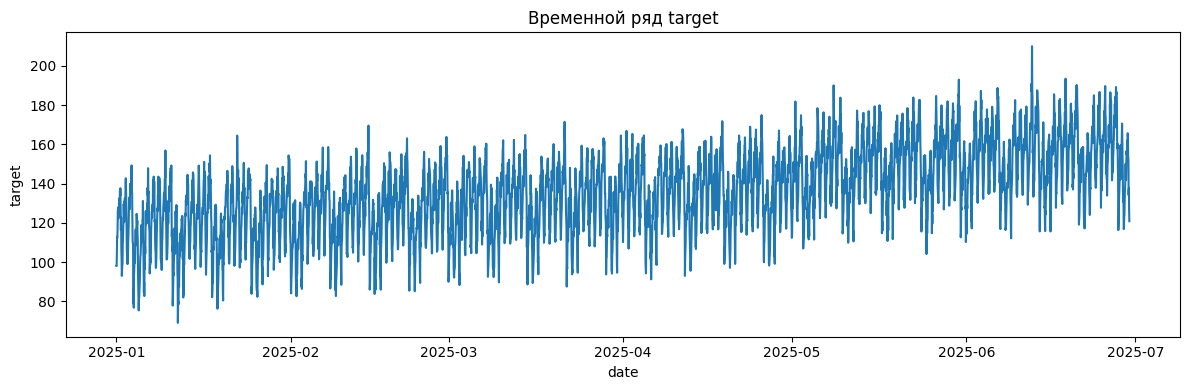

In [2]:
df = pd.read_csv("S12-hw-dataset.csv")

# приводим дату к datetime и сортируем
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Число наблюдений:", len(df))
print("Диапазон дат:", df["date"].min(), "→", df["date"].max())
print("Пропуски по колонкам:\n", df.isna().sum())

# базовый график ряда
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["target"])
plt.title("Временной ряд target")
plt.xlabel("date")
plt.ylabel("target")
plt.tight_layout()
plt.show()


Ряд почасовой, видно, что днём значения выше, ночью падают  
Есть лёгкий общий рост, но без каких‑то жёстких скачков или странных выбросов  
В целом выглядит довольно ровно  

#### Корректный temporal split

Train: 2025-01-01 00:00:00 → 2025-05-06 23:00:00 3024
Val:   2025-05-07 00:00:00 → 2025-06-02 23:00:00 648
Test:  2025-06-03 00:00:00 → 2025-06-29 23:00:00 648


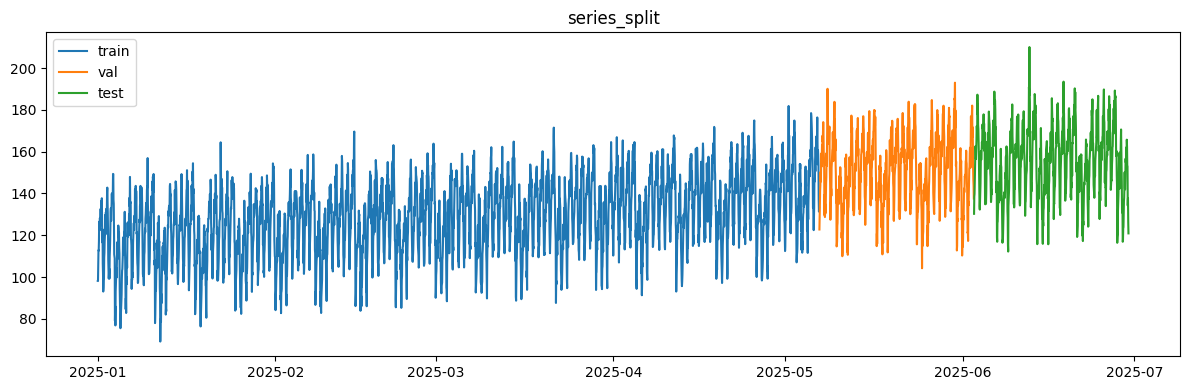

In [3]:
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:", train_df["date"].min(), "→", train_df["date"].max(), len(train_df))
print("Val:  ", val_df["date"].min(), "→", val_df["date"].max(), len(val_df))
print("Test: ", test_df["date"].min(), "→", test_df["date"].max(), len(test_df))

# визуализация split
plt.figure(figsize=(12, 4))
plt.plot(train_df["date"], train_df["target"], label="train")
plt.plot(val_df["date"], val_df["target"], label="val")
plt.plot(test_df["date"], test_df["target"], label="test")
plt.legend()
plt.title("series_split")
plt.tight_layout()
os.makedirs("artifacts/figures", exist_ok=True)
plt.savefig("artifacts/figures/series_split.png")
plt.show()


##### Почему random split — это плохо для временных рядов

random split тут вообще не подходит, тк данные перемешиваются  
Модель видит куски будущего в train и делает вид, что она умная (на самом деле просто подсмотрела ответы) 
В реальной жизни так не бывает (будущее не знаем, поэтому сплит должен идти строго по времени)
Получается утечка, метрики становятся липовыми

#### Признаки для baseline-моделей

In [4]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    df_feat = data.copy()
    df_feat = df_feat.sort_values("date").reset_index(drop=True)
    
    # лаги
    df_feat["lag_1"] = df_feat["target"].shift(1)
    df_feat["lag_7"] = df_feat["target"].shift(7)
    df_feat["lag_14"] = df_feat["target"].shift(14)
    
    # rolling по прошлому
    df_feat["rolling_mean_7"] = df_feat["target"].shift(1).rolling(window=7).mean()
    df_feat["rolling_std_7"] = df_feat["target"].shift(1).rolling(window=7).std()
    
    # календарные признаки
    df_feat["hour"] = df_feat["date"].dt.hour
    df_feat["dayofweek"] = df_feat["date"].dt.dayofweek
    
    return df_feat

df_feat = add_features(df)

# после построения признаков снова делаем split по времени
train_feat = df_feat.iloc[:train_end].copy()
val_feat = df_feat.iloc[train_end:val_end].copy()
test_feat = df_feat.iloc[val_end:].copy()

# выбрасываем строки с NaN (из-за лагов/rolling)
train_feat = train_feat.dropna().reset_index(drop=True)
val_feat = val_feat.dropna().reset_index(drop=True)
test_feat = test_feat.dropna().reset_index(drop=True)

print(train_feat.shape, val_feat.shape, test_feat.shape)


(3010, 9) (648, 9) (648, 9)


In [5]:
# Список признаков
feature_cols = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
    "hour", "dayofweek"
]
target_col = "target"


In [6]:
# Масштабирование только по train
scaler = StandardScaler()
scaler.fit(train_feat[feature_cols])

X_train = scaler.transform(train_feat[feature_cols])
y_train = train_feat[target_col].values

X_val = scaler.transform(val_feat[feature_cols])
y_val = val_feat[target_col].values

X_test = scaler.transform(test_feat[feature_cols])
y_test = test_feat[target_col].values


#### Метрики

In [7]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))   # <-- без squared=False
    mape_val = mape(y_true, y_pred)
    return mae, rmse, mape_val


#### Эксперименты

B1: naive-last

In [8]:
os.makedirs("artifacts", exist_ok=True)

runs = []

# B1: naive-last
def naive_last_forecast(train_series, test_series):
    last_val = train_series.iloc[-1]
    return np.full(shape=len(test_series), fill_value=last_val)

# на validation
y_train_series = train_df["target"]
y_val_series = val_df["target"]
y_test_series = test_df["target"]

val_pred_b1 = naive_last_forecast(y_train_series, y_val_series)
test_pred_b1 = naive_last_forecast(pd.concat([y_train_series, y_val_series]), y_test_series)

val_mae, val_rmse, val_mape = evaluate(y_val_series, val_pred_b1)
test_mae, test_rmse, test_mape = evaluate(y_test_series, test_pred_b1)

runs.append({
    "experiment_id": "B1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "temporal 70/15/15",
    "window_size": "",
    "horizon": 1,
    "model_summary": "naive-last",
    "features_summary": "last value",
    "scaler": "",
    "optimizer": "",
    "lr": "",
    "epochs_trained": "",
    "best_val_mae": val_mae,
    "best_val_rmse": val_rmse,
    "best_val_mape": val_mape,
    "test_mae": None,
    "test_rmse": None,
    "test_mape": None,
    "notes": ""
})


B2: moving-average

In [9]:
# B2: moving-average

WINDOW_MA = 24

def moving_average_forecast(series, window, forecast_len):
    ma = series.rolling(window=window).mean()
    last_ma = ma.iloc[-1]
    return np.full(shape=forecast_len, fill_value=last_ma)

val_pred_b2 = moving_average_forecast(y_train_series, WINDOW_MA, len(y_val_series))
test_pred_b2 = moving_average_forecast(pd.concat([y_train_series, y_val_series]), WINDOW_MA, len(y_test_series))

val_mae, val_rmse, val_mape = evaluate(y_val_series, val_pred_b2)
test_mae, test_rmse, test_mape = evaluate(y_test_series, test_pred_b2)

runs.append({
    "experiment_id": "B2",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "temporal 70/15/15",
    "window_size": "",
    "horizon": 1,
    "model_summary": f"moving-average window={WINDOW_MA}",
    "features_summary": "moving average of target",
    "scaler": "",
    "optimizer": "",
    "lr": "",
    "epochs_trained": "",
    "best_val_mae": val_mae,
    "best_val_rmse": val_rmse,
    "best_val_mape": val_mape,
    "test_mae": None,
    "test_rmse": None,
    "test_mape": None,
    "notes": ""
})


B3: Ridge

In [10]:
# B3: ridge-lag-features

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

val_pred_b3 = ridge.predict(X_val)
test_pred_b3 = ridge.predict(X_test)

val_mae, val_rmse, val_mape = evaluate(y_val, val_pred_b3)
test_mae, test_rmse, test_mape = evaluate(y_test, test_pred_b3)

runs.append({
    "experiment_id": "B3",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "temporal 70/15/15",
    "window_size": "",
    "horizon": 1,
    "model_summary": "Ridge",
    "features_summary": ", ".join(feature_cols),
    "scaler": "StandardScaler on train",
    "optimizer": "",
    "lr": "",
    "epochs_trained": "",
    "best_val_mae": val_mae,
    "best_val_rmse": val_rmse,
    "best_val_mape": val_mape,
    "test_mae": None,
    "test_rmse": None,
    "test_mape": None,
    "notes": ""
})


Оконное представление и GRU (R1)

In [11]:
WINDOW_SIZE = 24  # можно менять

def make_windows(series: pd.Series, window_size: int):
    values = series.values.astype("float32")
    X, y = [], []
    for i in range(len(values) - window_size):
        X.append(values[i:i+window_size])
        y.append(values[i+window_size])
    X = np.array(X)
    y = np.array(y)
    return X, y

scaler_rnn = StandardScaler()

train_scaled = scaler_rnn.fit_transform(train_df["target"].values.reshape(-1,1)).flatten()
val_scaled   = scaler_rnn.transform(val_df["target"].values.reshape(-1,1)).flatten()
test_scaled  = scaler_rnn.transform(test_df["target"].values.reshape(-1,1)).flatten()

# 2) Делаем окна
X_train_rnn, y_train_rnn = make_windows(pd.Series(train_scaled), WINDOW_SIZE)

# для val — берём хвост train + val
tmp_val = np.concatenate([train_scaled[-WINDOW_SIZE:], val_scaled])
X_val_rnn, y_val_rnn = make_windows(pd.Series(tmp_val), WINDOW_SIZE)

# для test — хвост train+val + test
tmp_test = np.concatenate([train_scaled[-WINDOW_SIZE:], val_scaled, test_scaled])
X_test_rnn, y_test_rnn = make_windows(pd.Series(tmp_test), WINDOW_SIZE)

# но нам нужны только последние len(test) окон
X_test_rnn = X_test_rnn[-len(test_scaled):]
y_test_rnn = y_test_rnn[-len(test_scaled):]

print(X_train_rnn.shape, X_val_rnn.shape, X_test_rnn.shape)


(3000, 24) (648, 24) (648, 24)


In [12]:
# Простой Dataset
class SeriesWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SeriesWindowDataset(X_train_rnn, y_train_rnn)
val_ds = SeriesWindowDataset(X_val_rnn, y_val_rnn)
test_ds = SeriesWindowDataset(X_test_rnn, y_test_rnn)

BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_ds = SeriesWindowDataset(X_test_rnn, y_test_rnn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)



In [13]:
# Модель GRU
class GRUForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        # x: (batch, seq_len)
        x = x.unsqueeze(-1)  # (batch, seq_len, 1)
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]
        out = self.fc(last_hidden)
        return out.squeeze(-1)

model = GRUForecast(input_size=1, hidden_size=32, num_layers=1).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
MAX_EPOCHS = 30


In [14]:
best_val_mae_gru = float("inf")
best_state_dict = None
history = {"train_loss": [], "val_loss": [], "val_mae": []}

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    
    model.eval()
    val_losses = []
    val_preds_all = []
    val_true_all = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_losses.append(loss.item())
            val_preds_all.append(preds.cpu().numpy())
            val_true_all.append(yb.cpu().numpy())
    
    val_preds_all = np.concatenate(val_preds_all)
    val_true_all = np.concatenate(val_true_all)
    val_mae = mean_absolute_error(val_true_all, val_preds_all)
    
    history["train_loss"].append(np.mean(train_losses))
    history["val_loss"].append(np.mean(val_losses))
    history["val_mae"].append(val_mae)
    
    if val_mae < best_val_mae_gru:
        best_val_mae_gru = val_mae
        best_state_dict = model.state_dict()
    
    print(f"Epoch {epoch}: train_loss={history['train_loss'][-1]:.4f}, val_loss={history['val_loss'][-1]:.4f}, val_mae={val_mae:.4f}")

# сохраняем лучшую модель
model.load_state_dict(best_state_dict)
torch.save(model.state_dict(), "artifacts/best_gru.pt")

best_gru_config = {
    "window_size": WINDOW_SIZE,
    "hidden_size": 32,
    "num_layers": 1,
    "batch_size": BATCH_SIZE,
    "lr": 1e-3,
    "max_epochs": MAX_EPOCHS,
    "seed": SEED,
    "device": str(device),
    "scaler": type(scaler_rnn).__name__,
    "normalization": "standard"
}

import json
with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(best_gru_config, f, indent=4)


Epoch 1: train_loss=0.7571, val_loss=1.1075, val_mae=0.8953
Epoch 2: train_loss=0.4135, val_loss=0.4413, val_mae=0.5651
Epoch 3: train_loss=0.2470, val_loss=0.2473, val_mae=0.4080
Epoch 4: train_loss=0.1805, val_loss=0.1800, val_mae=0.3437
Epoch 5: train_loss=0.1644, val_loss=0.1729, val_mae=0.3371
Epoch 6: train_loss=0.1579, val_loss=0.1693, val_mae=0.3337
Epoch 7: train_loss=0.1544, val_loss=0.1667, val_mae=0.3311
Epoch 8: train_loss=0.1520, val_loss=0.1652, val_mae=0.3294
Epoch 9: train_loss=0.1502, val_loss=0.1644, val_mae=0.3284
Epoch 10: train_loss=0.1488, val_loss=0.1640, val_mae=0.3279
Epoch 11: train_loss=0.1476, val_loss=0.1640, val_mae=0.3280
Epoch 12: train_loss=0.1465, val_loss=0.1641, val_mae=0.3283
Epoch 13: train_loss=0.1454, val_loss=0.1642, val_mae=0.3287
Epoch 14: train_loss=0.1441, val_loss=0.1644, val_mae=0.3289
Epoch 15: train_loss=0.1425, val_loss=0.1643, val_mae=0.3291
Epoch 16: train_loss=0.1401, val_loss=0.1641, val_mae=0.3286
Epoch 17: train_loss=0.1355, val_

In [15]:
# Оценка GRU на val и test
# val
model.eval()
val_preds_all = []
val_true_all = []
with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        val_preds_all.append(preds.cpu().numpy())
        val_true_all.append(yb.cpu().numpy())
val_preds_all = np.concatenate(val_preds_all)
val_true_all = np.concatenate(val_true_all)

val_mae, val_rmse, val_mape = evaluate(val_true_all, val_preds_all)

# test
test_preds_all = []
test_true_all = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        test_preds_all.append(preds.cpu().numpy())
        test_true_all.append(yb.cpu().numpy())

test_preds_all = np.concatenate(test_preds_all)
test_true_all = np.concatenate(test_true_all)
# обратное масштабирование
test_preds_all = scaler_rnn.inverse_transform(test_preds_all.reshape(-1,1)).flatten()
test_true_all  = scaler_rnn.inverse_transform(test_true_all.reshape(-1,1)).flatten()


test_mae, test_rmse, test_mape = evaluate(test_true_all, test_preds_all)

runs.append({
    "experiment_id": "R1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": "temporal 70/15/15",
    "window_size": WINDOW_SIZE,
    "horizon": 1,
    "model_summary": "GRUForecast(hidden_size=32, num_layers=1)",
    "features_summary": "raw target windows",
    "scaler": type(scaler_rnn).__name__,
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": len(history["train_loss"]),
    "best_val_mae": val_mae,
    "best_val_rmse": val_rmse,
    "best_val_mape": val_mape,
    "test_mae": test_mae,
    "test_rmse": test_rmse,
    "test_mape": test_mape,
    "notes": ""
})


#### runs.csv и графики сравнения

In [16]:
runs_df = pd.DataFrame(runs)
runs_df.to_csv("artifacts/runs.csv", index=False)
runs_df


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,temporal 70/15/15,,1,naive-last,last value,,,,,20.340093,24.364325,12.856044,NaN,NaN,NaN,
1,B2,forecasting,S12-hw-dataset.csv,42,temporal 70/15/15,,1,moving-average window=24,moving average of target,,,,,14.266139,17.258000,9.829842,NaN,NaN,NaN,
2,B3,forecasting,S12-hw-dataset.csv,42,temporal 70/15/15,,1,Ridge,"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler on train,,,,6.360191,7.886871,4.282035,NaN,NaN,NaN,
3,R1,forecasting,S12-hw-dataset.csv,42,temporal 70/15/15,24,1,"GRUForecast(hidden_size=32, num_layers=1)",raw target windows,StandardScaler,Adam,0.001,30,0.306066,0.393156,127.319954,6.833127,8.637035,4.370811,


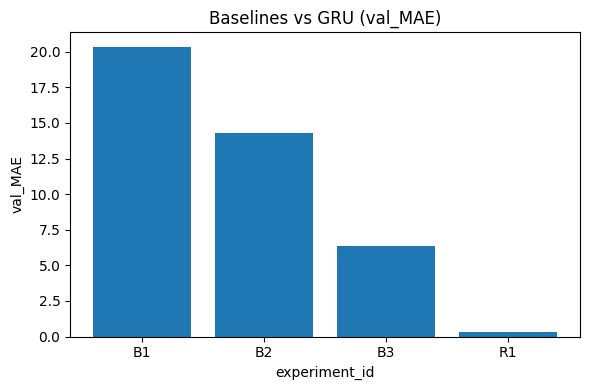

In [17]:
plt.figure(figsize=(6,4))
plt.bar(runs_df["experiment_id"], runs_df["best_val_mae"])
plt.xlabel("experiment_id")
plt.ylabel("val_MAE")
plt.title("Baselines vs GRU (val_MAE)")
plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()


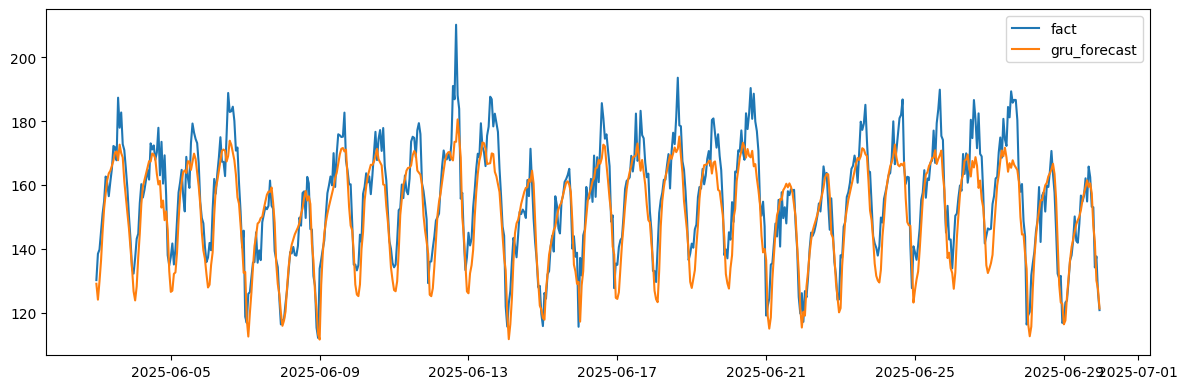

In [18]:
test_dates = test_df["date"].iloc[-len(test_true_all):].reset_index(drop=True)

plt.figure(figsize=(12,4))
plt.plot(test_dates, test_true_all, label="fact")
plt.plot(test_dates, test_preds_all, label="gru_forecast")
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()
